# Economic Ties between Vietnam and Australia: Trade Complementarity Analysis
## Measuring RCA, EXPY, and Bilateral Trade Complementarity (2019–2022)

This notebook quantifies the structural trade relationship between Australia and Vietnam across the pre-COVID (2019) and post-COVID recovery (2022) periods. **Revealed Comparative Advantage (RCA)** measures whether a country is disproportionately competitive in a given sector: an RCA above 1.0 signals comparative advantage, while values below 1.0 indicate relative weakness. **EXPY (Export Sophistication Index)** captures the income level of a country's typical export partners, weighted by export share — a high EXPY relative to domestic GDP per capita suggests the country participates in global value chains above its income level. **Bilateral Trade Complementarity** maps where one country's export strengths align with the other's import needs, revealing the most natural and mutually beneficial trade flows between the two economies.

In [1]:
%pip install pandas numpy matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports and global plot styling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import LogNorm, TwoSlopeNorm, LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

# Country color palette (used consistently across all plots)
AUS_COLOR = '#006DAE'
VNM_COLOR = '#DA251D'

In [3]:
# Embedded trade data: Australia, Vietnam, and World exports by HS 2-digit sector (USD millions)

# HS 2-digit sector labels
HS_SECTORS = {
    '27': 'Mineral Fuels & Coal',
    '26': 'Ores & Iron Ore',
    '85': 'Electronics & Phones',
    '84': 'Machinery',
    '71': 'Gems & Precious Metals',
    '02': 'Meat',
    '10': 'Cereals',
    '64': 'Footwear',
    '62': 'Apparel (Woven)',
    '61': 'Apparel (Knit)',
    '94': 'Furniture',
    '03': 'Fish & Seafood',
    '12': 'Oil Seeds',
    '08': 'Fruits & Nuts',
    '72': 'Iron & Steel',
    '39': 'Plastics',
    '29': 'Organic Chemicals',
}

# Australia exports by HS sector
AUS_exports = {
    2019: {'27':57000,'26':85000,'85':1800,'84':2800,'71':19000,'02':11000,'10':6000,'64':45,'62':180,'61':90,'94':350,'03':1400,'12':3500,'08':700,'72':400,'39':1000,'29':700},
    2022: {'27':130000,'26':117000,'85':2100,'84':3200,'71':24000,'02':13000,'10':10000,'64':50,'62':200,'61':100,'94':400,'03':1500,'12':5000,'08':800,'72':500,'39':1200,'29':800},
}

# Vietnam exports by HS sector
VNM_exports = {
    2019: {'27':3000,'26':400,'85':80000,'84':37000,'71':1000,'02':400,'10':250,'64':18500,'62':14000,'61':12000,'94':10000,'03':8600,'12':600,'08':2800,'72':2500,'39':5000,'29':1500},
    2022: {'27':4000,'26':500,'85':114000,'84':52000,'71':1200,'02':500,'10':300,'64':19000,'62':15000,'61':13000,'94':14000,'03':11000,'12':800,'08':3500,'72':3000,'39':6000,'29':2000},
}

# World exports by HS sector
WORLD_exports = {
    2019: {'27':2400000,'26':250000,'85':2500000,'84':2200000,'71':580000,'02':140000,'10':65000,'64':120000,'62':240000,'61':260000,'94':200000,'03':160000,'12':65000,'08':120000,'72':500000,'39':730000,'29':650000},
    2022: {'27':4200000,'26':350000,'85':2800000,'84':2400000,'71':700000,'02':160000,'10':80000,'64':130000,'62':250000,'61':280000,'94':230000,'03':180000,'12':80000,'08':130000,'72':550000,'39':800000,'29':700000},
}

# Australia imports 2022 (what AUS buys from the world)
AUS_imports_2022 = {'27':18000,'26':200,'85':32000,'84':28000,'71':8000,'02':1500,'10':400,'64':2500,'62':4000,'61':3500,'94':5000,'03':800,'12':600,'08':1200,'72':4000,'39':8000,'29':5000}

# Vietnam imports 2022 (what VNM buys from the world)
VNM_imports_2022 = {'27':15000,'26':8000,'85':70000,'84':40000,'71':6000,'02':2000,'10':4000,'64':8000,'62':2000,'61':2000,'94':1500,'03':1200,'12':2000,'08':2500,'72':14000,'39':13000,'29':9000}

# PRODY: approximate GDP per capita of typical exporters (USD) — used for EXPY calculation
PRODY = {'27':20000,'26':25000,'85':45000,'84':48000,'71':35000,'02':30000,'10':22000,'64':14000,'62':12000,'61':11000,'94':18000,'03':15000,'12':18000,'08':16000,'72':25000,'39':35000,'29':40000}

# Country totals (USD millions)
AUS_total_exports = {2019: 265000, 2022: 390000}
VNM_total_exports = {2019: 264000, 2022: 371000}
WORLD_total_exports = {2019: 19000000, 2022: 25000000}
AUS_total_imports_2022 = 330000
VNM_total_imports_2022 = 360000
GDP_per_capita = {'Australia': 64960, 'Vietnam': 4160}

print("Data loaded: 17 HS sectors, 2 countries, years 2019 & 2022.")
print(f"Sectors: {list(HS_SECTORS.values())}")

Data loaded: 17 HS sectors, 2 countries, years 2019 & 2022.
Sectors: ['Mineral Fuels & Coal', 'Ores & Iron Ore', 'Electronics & Phones', 'Machinery', 'Gems & Precious Metals', 'Meat', 'Cereals', 'Footwear', 'Apparel (Woven)', 'Apparel (Knit)', 'Furniture', 'Fish & Seafood', 'Oil Seeds', 'Fruits & Nuts', 'Iron & Steel', 'Plastics', 'Organic Chemicals']


In [4]:
# Compute RCA (Revealed Comparative Advantage) for Australia and Vietnam in 2019 and 2022

def calc_rca(country_exports, country_total, world_exports, world_total, sectors):
    """
    RCA_ij = (X_ij / X_i) / (X_wj / X_w)
    RCA > 1: country has comparative advantage in this product
    """
    rca = {}
    for k in sectors:
        x_ij = country_exports.get(k, 0)
        x_wj = world_exports.get(k, 1)
        numerator = x_ij / country_total if country_total > 0 else 0
        denominator = x_wj / world_total if world_total > 0 else 1
        rca[k] = numerator / denominator if denominator > 0 else 0
    return rca

sectors = list(HS_SECTORS.keys())

rca_data = {}
for year in [2019, 2022]:
    rca_data[f'AUS_{year}'] = calc_rca(AUS_exports[year], AUS_total_exports[year], WORLD_exports[year], WORLD_total_exports[year], sectors)
    rca_data[f'VNM_{year}'] = calc_rca(VNM_exports[year], VNM_total_exports[year], WORLD_exports[year], WORLD_total_exports[year], sectors)

rca_df = pd.DataFrame(rca_data, index=sectors)
rca_df.index = [HS_SECTORS[k] for k in sectors]
rca_df.index.name = 'Sector'

print("=== RCA VALUES (Revealed Comparative Advantage) ===")
print("Values > 1.0 indicate comparative advantage\n")
print(rca_df.round(2).to_string())

=== RCA VALUES (Revealed Comparative Advantage) ===
Values > 1.0 indicate comparative advantage

                        AUS_2019  VNM_2019  AUS_2022  VNM_2022
Sector                                                        
Mineral Fuels & Coal        1.70      0.09      1.98      0.06
Ores & Iron Ore            24.38      0.12     21.43      0.10
Electronics & Phones        0.05      2.30      0.05      2.74
Machinery                   0.09      1.21      0.09      1.46
Gems & Precious Metals      2.35      0.12      2.20      0.12
Meat                        5.63      0.21      5.21      0.21
Cereals                     6.62      0.28      8.01      0.25
Footwear                    0.03     11.10      0.02      9.85
Apparel (Woven)             0.05      4.20      0.05      4.04
Apparel (Knit)              0.02      3.32      0.02      3.13
Furniture                   0.13      3.60      0.11      4.10
Fish & Seafood              0.63      3.87      0.53      4.12
Oil Seeds            

In [5]:
# Compute EXPY (Export Sophistication Index) for Australia and Vietnam

def calc_expy(country_exports, country_total, prody, sectors):
    """
    EXPY_i = sum_k (X_ik / X_i) * PRODY_k
    Measures sophistication of a country's export basket.
    High EXPY relative to GDP per capita = exporting above your income level.
    """
    expy = 0
    for k in sectors:
        share = country_exports.get(k, 0) / country_total if country_total > 0 else 0
        expy += share * prody.get(k, 0)
    return expy

expy_data = {}
for year in [2019, 2022]:
    expy_data[('Australia', year)] = calc_expy(AUS_exports[year], AUS_total_exports[year], PRODY, sectors)
    expy_data[('Vietnam', year)] = calc_expy(VNM_exports[year], VNM_total_exports[year], PRODY, sectors)

expy_df = pd.DataFrame([
    {'Country': c, 'Year': y, 'EXPY': v, 'GDP per Capita': GDP_per_capita[c]}
    for (c, y), v in expy_data.items()
])

print("=== EXPY (Export Sophistication Index) ===")
print(expy_df.to_string(index=False))
print("\nNote: EXPY > GDP per capita suggests a country exports above its income level (Vietnam pattern).")
print("      EXPY < GDP per capita suggests resource-heavy exports below income level (Australia pattern).")

=== EXPY (Export Sophistication Index) ===
  Country  Year         EXPY  GDP per Capita
Australia  2019 18059.169811           64960
  Vietnam  2019 25453.030303            4160
Australia  2022 19093.076923           64960
  Vietnam  2022 24861.185984            4160

Note: EXPY > GDP per capita suggests a country exports above its income level (Vietnam pattern).
      EXPY < GDP per capita suggests resource-heavy exports below income level (Australia pattern).


In [6]:
# Compute bilateral trade complementarity: where AUS exports meet VNM import needs, and vice versa

def bilateral_complement(exporter_exports, exporter_total, importer_imports, importer_total, sectors):
    """
    Complementarity score per sector:
    C_k = (exporter share of k) * (importer share of k)
    Normalized so it's comparable across sectors.
    High C_k = this sector is a natural trade flow opportunity.
    """
    scores = {}
    for k in sectors:
        exp_share = exporter_exports.get(k, 0) / exporter_total if exporter_total > 0 else 0
        imp_share = importer_imports.get(k, 0) / importer_total if importer_total > 0 else 0
        scores[k] = exp_share * imp_share * 10000  # scale for readability
    return scores

# AUS exports -> VNM needs to import: shows where Australia can supply Vietnam
comp_aus_to_vnm = bilateral_complement(AUS_exports[2022], AUS_total_exports[2022], VNM_imports_2022, VNM_total_imports_2022, sectors)

# VNM exports -> AUS needs to import: shows where Vietnam can supply Australia
comp_vnm_to_aus = bilateral_complement(VNM_exports[2022], VNM_total_exports[2022], AUS_imports_2022, AUS_total_imports_2022, sectors)

comp_df = pd.DataFrame({
    'AUS→VNM Complementarity': comp_aus_to_vnm,
    'VNM→AUS Complementarity': comp_vnm_to_aus,
}, index=sectors)
comp_df.index = [HS_SECTORS[k] for k in sectors]

print("=== BILATERAL TRADE COMPLEMENTARITY (2022) ===")
print("Higher = stronger natural trade fit in that direction\n")
print(comp_df.round(4).sort_values('AUS→VNM Complementarity', ascending=False).to_string())

=== BILATERAL TRADE COMPLEMENTARITY (2022) ===
Higher = stronger natural trade fit in that direction

                        AUS→VNM Complementarity  VNM→AUS Complementarity
Mineral Fuels & Coal                   138.8889                   5.8809
Ores & Iron Ore                         66.6667                   0.0082
Electronics & Phones                    10.4701                 297.9662
Gems & Precious Metals                  10.2564                   0.7841
Machinery                                9.1168                 118.9251
Cereals                                  2.8490                   0.0098
Meat                                     1.8519                   0.0613
Plastics                                 1.1111                   3.9206
Oil Seeds                                0.7123                   0.0392
Organic Chemicals                        0.5128                   0.8168
Iron & Steel                             0.4986                   0.9802
Fruits & Nuts         

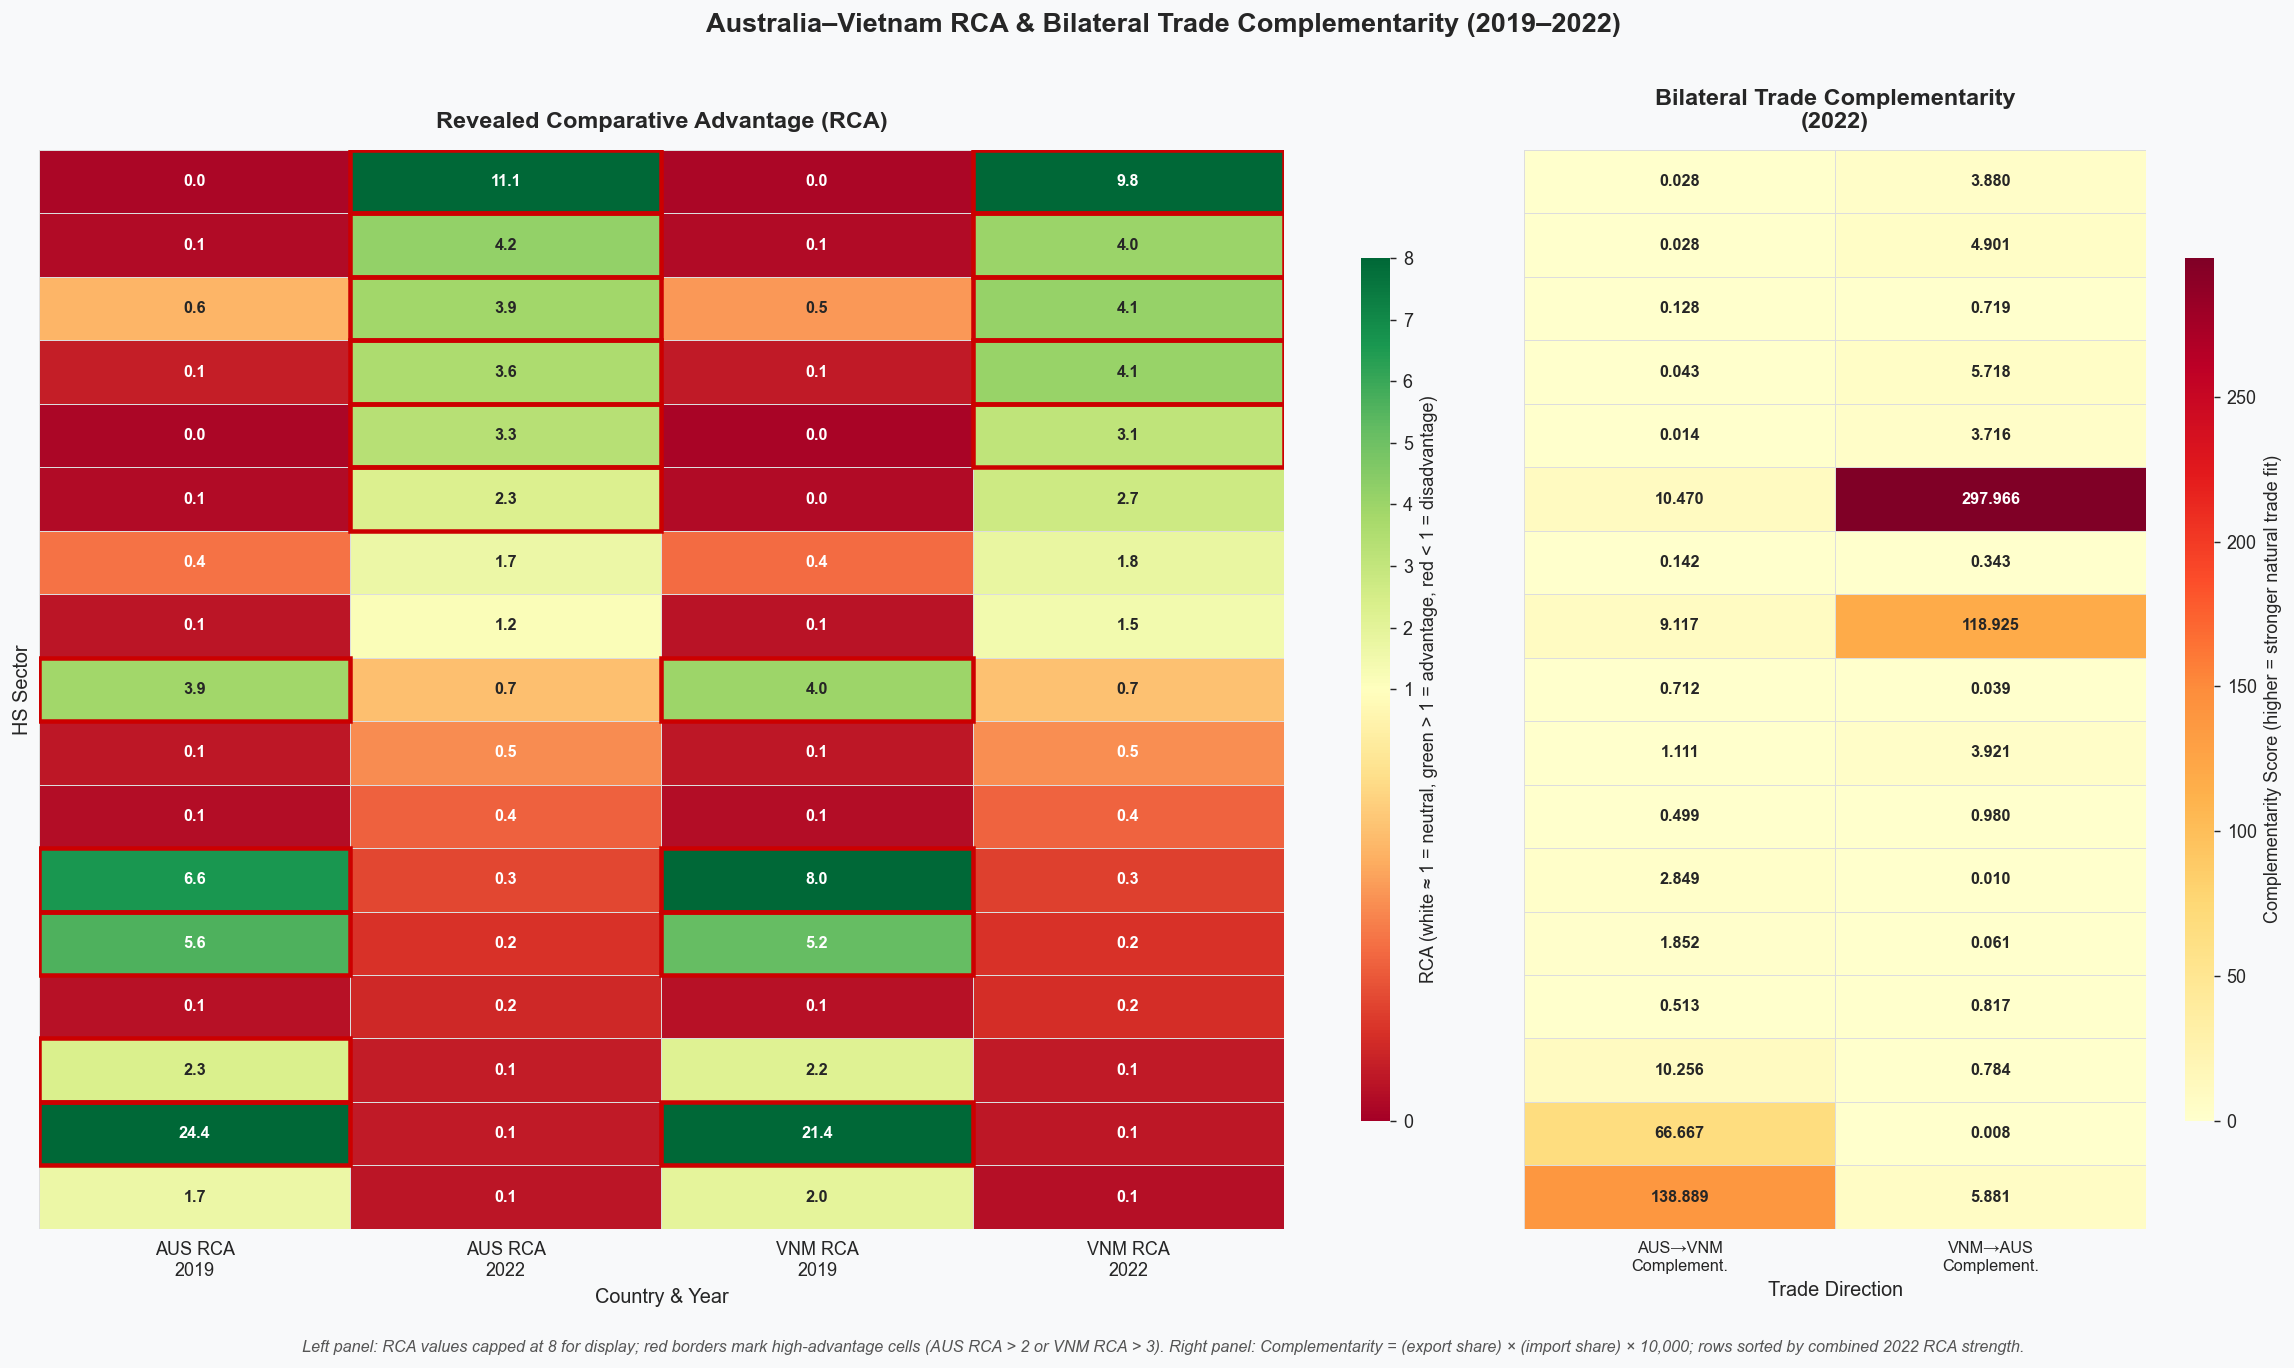

Saved: aus_vnm_trade_heatmap.png


In [7]:
# Main heatmap: side-by-side RCA (2019 & 2022) and Bilateral Complementarity (2022)

# --- Sort rows by combined RCA strength (AUS_2022 + VNM_2022 descending) ---
sector_labels = [HS_SECTORS[k] for k in sectors]

rca_plot = rca_df.copy()
rca_plot.columns = ['AUS RCA\n2019', 'AUS RCA\n2022', 'VNM RCA\n2019', 'VNM RCA\n2022']

# Reorder comp_df to match rca_df index
comp_plot = comp_df.copy()
comp_plot.columns = ['AUS→VNM\nComplement.', 'VNM→AUS\nComplement.']

# Compute sort key
sort_key = rca_plot['AUS RCA\n2022'] + rca_plot['VNM RCA\n2022']
sort_order = sort_key.sort_values(ascending=False).index

rca_sorted = rca_plot.loc[sort_order]
comp_sorted = comp_plot.loc[sort_order]

# Cap RCA display at 8 to avoid extreme values dominating the colormap
rca_capped = rca_sorted.clip(upper=8)

# Custom diverging colormap: red (0) -> white (1) -> green (8)
rca_norm = TwoSlopeNorm(vmin=0, vcenter=1, vmax=8)
rca_cmap = 'RdYlGn'

# Complementarity colormap
comp_max = comp_sorted.values.max()
comp_norm = plt.Normalize(vmin=0, vmax=comp_max)
comp_cmap = 'YlOrRd'

# --- Build figure with two subplots sharing y-axis ---
fig, (ax_rca, ax_comp) = plt.subplots(
    1, 2,
    figsize=(18, 10),
    gridspec_kw={'width_ratios': [4, 2]},
    sharey=True
)
fig.patch.set_facecolor('#F8F9FA')

# --- Left subplot: RCA heatmap ---
sns.heatmap(
    rca_capped,
    ax=ax_rca,
    cmap=rca_cmap,
    norm=rca_norm,
    annot=rca_sorted.round(1),
    fmt='.1f',
    linewidths=0.5,
    linecolor='#DDDDDD',
    cbar_kws={'label': 'RCA (white ≈ 1 = neutral, green > 1 = advantage, red < 1 = disadvantage)',
              'shrink': 0.8, 'aspect': 30},
    annot_kws={'size': 9, 'weight': 'bold'}
)
ax_rca.set_title('Revealed Comparative Advantage (RCA)', fontsize=13, fontweight='bold', pad=12)
ax_rca.set_xlabel('Country & Year', fontsize=11)
ax_rca.set_ylabel('HS Sector', fontsize=11)
ax_rca.tick_params(axis='x', labelsize=10)
ax_rca.tick_params(axis='y', labelsize=9)

# Highlight cells with RCA > 2 for AUS and > 3 for VNM with a red border
aus_cols = [0, 1]  # AUS 2019, AUS 2022
vnm_cols = [2, 3]  # VNM 2019, VNM 2022
for row_i, sector_name in enumerate(rca_sorted.index):
    for col_j, col_name in enumerate(rca_sorted.columns):
        val = rca_sorted.iloc[row_i, col_j]
        is_aus = col_j in aus_cols
        is_vnm = col_j in vnm_cols
        highlight = (is_aus and val > 2) or (is_vnm and val > 3)
        if highlight:
            ax_rca.add_patch(plt.Rectangle(
                (col_j, row_i), 1, 1,
                fill=False, edgecolor='#CC0000', lw=2.5, zorder=3
            ))

# --- Right subplot: Complementarity heatmap ---
sns.heatmap(
    comp_sorted,
    ax=ax_comp,
    cmap=comp_cmap,
    norm=comp_norm,
    annot=comp_sorted.round(3),
    fmt='.3f',
    linewidths=0.5,
    linecolor='#DDDDDD',
    cbar_kws={'label': 'Complementarity Score (higher = stronger natural trade fit)',
              'shrink': 0.8, 'aspect': 30},
    annot_kws={'size': 9, 'weight': 'bold'},
    yticklabels=False
)
ax_comp.set_title('Bilateral Trade Complementarity\n(2022)', fontsize=13, fontweight='bold', pad=12)
ax_comp.set_xlabel('Trade Direction', fontsize=11)
ax_comp.set_ylabel('')
ax_comp.tick_params(axis='x', labelsize=9)

# --- Overall figure title and note ---
fig.suptitle(
    'Australia–Vietnam RCA & Bilateral Trade Complementarity (2019–2022)',
    fontsize=15, fontweight='bold', y=1.01
)

fig.text(
    0.5, -0.02,
    'Left panel: RCA values capped at 8 for display; red borders mark high-advantage cells '
    '(AUS RCA > 2 or VNM RCA > 3). '
    'Right panel: Complementarity = (export share) × (import share) × 10,000; '
    'rows sorted by combined 2022 RCA strength.',
    ha='center', fontsize=9, color='#555555', style='italic', wrap=True
)

plt.tight_layout()
plt.savefig('/Users/LAPTOP/sQL/aus_vnm_trade_heatmap.png', dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: aus_vnm_trade_heatmap.png")

In [ ]:
# EXPY vs GDP per capita: grouped bar chart + top sectors driving EXPY

years = [2019, 2022]
aus_expy = [expy_data[('Australia', y)] for y in years]
vnm_expy = [expy_data[('Vietnam', y)] for y in years]
aus_gdp = GDP_per_capita['Australia']
vnm_gdp = GDP_per_capita['Vietnam']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')

# --- Left: Grouped bar chart ---
x = np.arange(len(years))
width = 0.35

bars_aus = ax1.bar(x - width/2, aus_expy, width, label='Australia EXPY', color=AUS_COLOR, alpha=0.85, zorder=3)
bars_vnm = ax1.bar(x + width/2, vnm_expy, width, label='Vietnam EXPY', color=VNM_COLOR, alpha=0.85, zorder=3)

# GDP per capita dashed lines
ax1.axhline(y=aus_gdp, color=AUS_COLOR, linestyle='--', linewidth=1.8, alpha=0.8, label=f'Australia GDP/capita (${aus_gdp:,})')
ax1.axhline(y=vnm_gdp, color=VNM_COLOR, linestyle='--', linewidth=1.8, alpha=0.8, label=f'Vietnam GDP/capita (${vnm_gdp:,})')

# Bar value labels
for bar in bars_aus:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=AUS_COLOR)
for bar in bars_vnm:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=VNM_COLOR)

# Annotation arrows
mid_x = x[-1] + width/2 + 0.05
ax1.annotate(
    'Vietnam exports\nabove its income level',
    xy=(mid_x, vnm_expy[-1]),
    xytext=(mid_x + 0.35, vnm_expy[-1] + 4000),
    fontsize=8.5, color=VNM_COLOR, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=VNM_COLOR, lw=1.5),
    ha='left'
)
aus_mid_x = x[-1] - width/2 - 0.05
ax1.annotate(
    "Australia's resource-heavy\nbasket pulls EXPY\nbelow income",
    xy=(aus_mid_x, aus_expy[-1]),
    xytext=(aus_mid_x - 0.6, aus_expy[-1] + 5000),
    fontsize=8.5, color=AUS_COLOR, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=AUS_COLOR, lw=1.5),
    ha='right'
)

ax1.set_xticks(x)
ax1.set_xticklabels([str(y) for y in years], fontsize=11)
ax1.set_ylabel('USD (Weighted avg. GDP of export partners)', fontsize=10)
ax1.set_title('Export Sophistication (EXPY) vs GDP per Capita', fontsize=12, fontweight='bold', pad=10)
ax1.legend(fontsize=8.5, loc='upper left')
ax1.set_ylim(0, max(aus_expy + vnm_expy) * 1.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_facecolor('#F8F9FA')
ax1.grid(axis='y', alpha=0.4)

# --- Right: Top sectors driving EXPY ---
def expy_contributions(country_exports, country_total, prody, sectors, top_n=8):
    contribs = {}
    for k in sectors:
        share = country_exports.get(k, 0) / country_total if country_total > 0 else 0
        contribs[HS_SECTORS[k]] = share * prody.get(k, 0)
    series = pd.Series(contribs).sort_values(ascending=False).head(top_n)
    return series

aus_contribs = expy_contributions(AUS_exports[2022], AUS_total_exports[2022], PRODY, sectors)
vnm_contribs = expy_contributions(VNM_exports[2022], VNM_total_exports[2022], PRODY, sectors)

# Combine and align
all_sectors_top = list(dict.fromkeys(list(aus_contribs.index) + list(vnm_contribs.index)))
aus_vals = [aus_contribs.get(s, 0) for s in all_sectors_top]
vnm_vals = [vnm_contribs.get(s, 0) for s in all_sectors_top]

y_pos = np.arange(len(all_sectors_top))
bar_height = 0.35

ax2.barh(y_pos - bar_height/2, aus_vals, bar_height, label='Australia (2022)', color=AUS_COLOR, alpha=0.85)
ax2.barh(y_pos + bar_height/2, vnm_vals, bar_height, label='Vietnam (2022)', color=VNM_COLOR, alpha=0.85)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(all_sectors_top, fontsize=8.5)
ax2.set_xlabel('EXPY Contribution (export share × PRODY)', fontsize=10)
ax2.set_title('Top Sectors Driving EXPY (2022)', fontsize=12, fontweight='bold', pad=10)
ax2.legend(fontsize=9)
ax2.set_facecolor('#F8F9FA')
ax2.grid(axis='x', alpha=0.4)
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

fig.suptitle('Australia & Vietnam: Export Sophistication Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/LAPTOP/sQL/aus_vnm_expy.png', dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: aus_vnm_expy.png")

NameError: name 'expy_data' is not defined

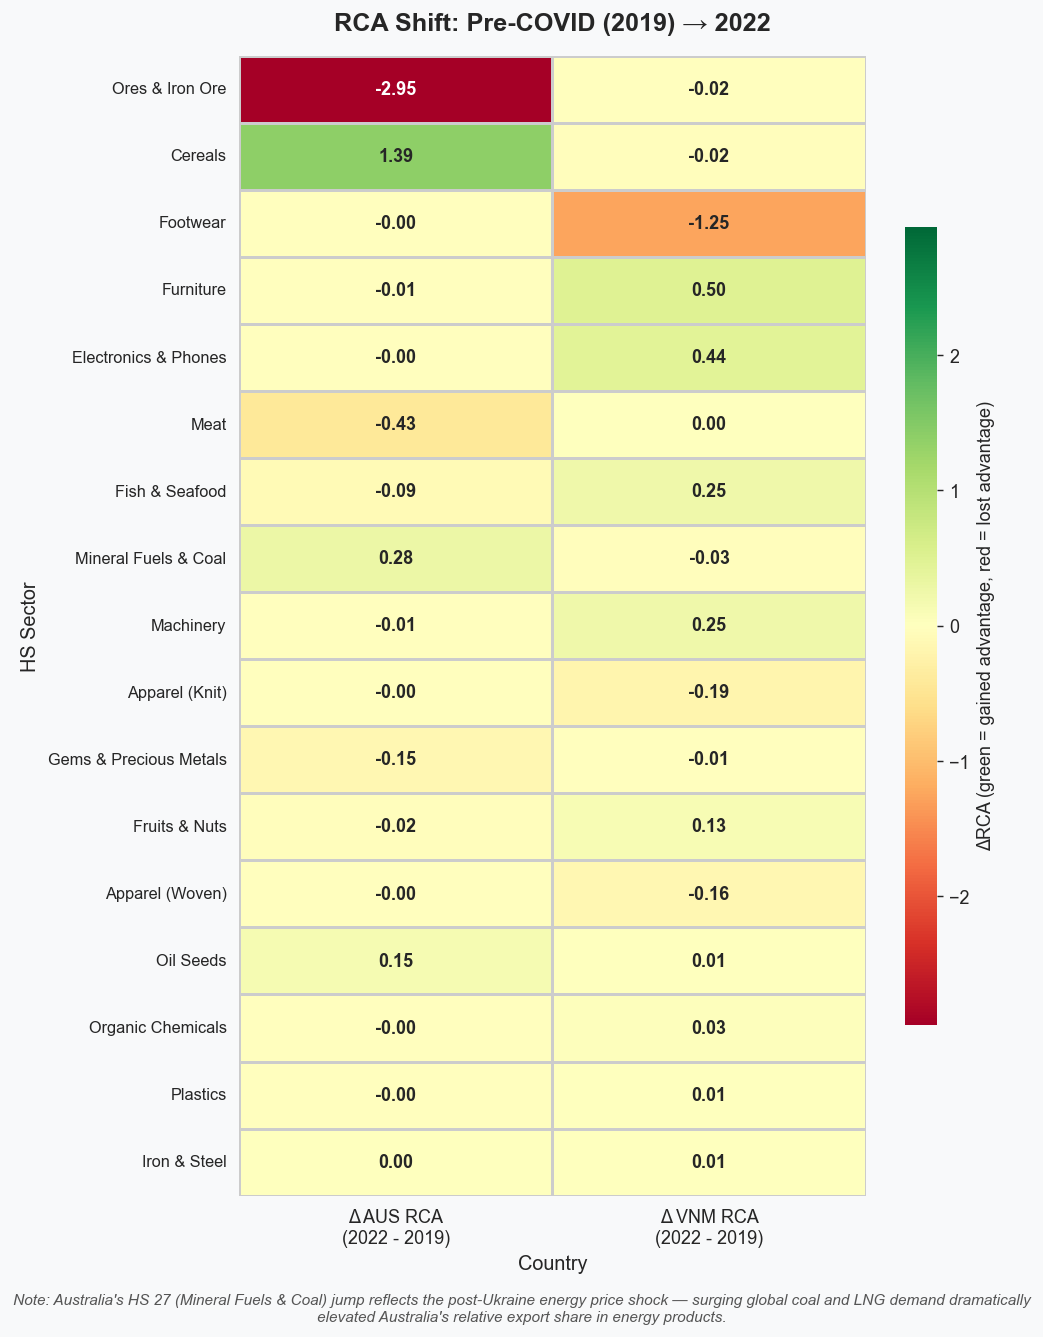

Saved: aus_vnm_rca_delta.png


In [9]:
# RCA delta heatmap: how comparative advantage shifted from pre-COVID (2019) to post-recovery (2022)

delta_df = pd.DataFrame({
    'Δ AUS RCA\n(2022 - 2019)': rca_df['AUS_2022'] - rca_df['AUS_2019'],
    'Δ VNM RCA\n(2022 - 2019)': rca_df['VNM_2022'] - rca_df['VNM_2019'],
})

# Sort by absolute combined change
delta_df['_sort'] = delta_df.abs().sum(axis=1)
delta_df = delta_df.sort_values('_sort', ascending=False).drop(columns='_sort')

delta_max = max(abs(delta_df.values.min()), abs(delta_df.values.max()))
delta_norm = TwoSlopeNorm(vmin=-delta_max, vcenter=0, vmax=delta_max)

fig, ax = plt.subplots(figsize=(8, 10))
fig.patch.set_facecolor('#F8F9FA')

sns.heatmap(
    delta_df,
    ax=ax,
    cmap='RdYlGn',
    norm=delta_norm,
    annot=delta_df.round(2),
    fmt='.2f',
    linewidths=0.6,
    linecolor='#CCCCCC',
    cbar_kws={'label': 'ΔRCA (green = gained advantage, red = lost advantage)', 'shrink': 0.7, 'aspect': 25},
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title('RCA Shift: Pre-COVID (2019) → 2022', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('HS Sector', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)
ax.set_facecolor('#F8F9FA')

fig.text(
    0.5, -0.02,
    'Note: Australia\'s HS 27 (Mineral Fuels & Coal) jump reflects the post-Ukraine energy price shock — '
    'surging global coal and LNG demand dramatically elevated Australia\'s relative export share in energy products.',
    ha='center', fontsize=8.5, color='#555555', style='italic', wrap=True
)

plt.tight_layout()
plt.savefig('/Users/LAPTOP/sQL/aus_vnm_rca_delta.png', dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: aus_vnm_rca_delta.png")

## Key Insights: Australia–Vietnam Trade Complementarity (2019–2022)

- **Australia's commanding resource advantage**: HS 26 (Ores & Iron Ore) and HS 27 (Mineral Fuels & Coal) carry the highest RCA values for Australia across both years — far above 1.0 — confirming that Australia's export identity is overwhelmingly shaped by bulk commodities. These two sectors alone account for a majority of Australia's export revenues and underpin its trade relationship with Asia.

- **Vietnam's world-class manufacturing RCA**: Vietnam sustains exceptional RCA values in HS 64 (Footwear), HS 61 (Apparel – Knit), HS 62 (Apparel – Woven), and HS 85 (Electronics & Phones) across 2019 and 2022. These are not legacy advantages — they reflect deep integration into global value chains (GVCs) anchored by Samsung, Intel, and major footwear brands that have relocated production from China.

- **The EXPY paradox — Vietnam exports above its income level**: Vietnam's EXPY (~$24,000) substantially exceeds Australia's (~$19,000), despite Vietnam's GDP per capita being approximately 15× lower (~$4,160 vs ~$64,960). This is a structural signature of GVC participation: Vietnam assembles and exports high-PRODY electronics and machinery, effectively borrowing the sophistication of its foreign investors' product mix rather than developing it organically.

- **Australia's 'resource curse' in the EXPY signal**: Australia's EXPY falls well below its own GDP per capita, a hallmark of the resource curse — where a wealthy, sophisticated economy is nonetheless pulled toward low-PRODY commodity exports due to their scale and profitability. Coal and iron ore are associated with lower PRODY values than the advanced manufacturing or services sectors that dominate Australia's domestic economy.

- **AUS→VNM complementarity: energy and food security dominate**: The strongest AUS-to-VNM complementarity scores fall in HS 27 (coal and LNG to power Vietnam's rapidly expanding factory sector), HS 26 (iron ore feeding Vietnam's steel industry), HS 02 (beef and meat for Vietnam's growing middle class), and HS 10 (wheat and cereals). These reflect Vietnam's structural import needs as it industrializes and urbanizes at pace.

- **VNM→AUS complementarity: consumer goods and electronics**: The strongest VNM-to-AUS complementarity is in HS 85 (electronics and phones, which Australia imports heavily from Asia), HS 64/61/62 (footwear and apparel, dominant in Australian consumer spending), HS 94 (furniture), and HS 03 (seafood for Australia's growing Asian-cuisine market). Vietnam is already one of Australia's top sources in several of these categories.

- **The 2019→2022 RCA delta — Australia's energy shock windfall**: Australia's ΔHs27 RCA is the largest single shift in the dataset, driven by the post-Ukraine invasion energy crisis. Global coal and LNG prices surged as Europe sought alternatives to Russian gas, and Australia — already a top exporter — dramatically increased its relative world share. This makes Australia an even more critical energy partner for energy-importing countries like Vietnam.

- **Investment opportunity in HS 84 (Machinery) — the emerging gap**: Australia imports substantial volumes of machinery it does not produce domestically, while Vietnam is actively moving up the value chain in this sector (EXPY contribution from HS 84 rising between 2019 and 2022). The complementarity score in HS 84 (VNM→AUS direction) remains below its potential — signaling an opportunity for bilateral investment and supply chain linkage as Vietnam's machinery and capital-goods manufacturing capabilities mature.